<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/MPC_Narx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# ============================================================
# NARX OTIMIZADO POR NSGA-II RÁPIDO + TESTE RECURSIVO + MPC
# Versão completa para Google Colab
# ============================================================

!pip -q install pymoo openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

warnings.filterwarnings("ignore")


In [22]:

# ============================================================
# 1) CONFIGURAÇÃO DO USUÁRIO
# ============================================================

USAR_UPLOAD = True
ARQUIVO_EXCEL = "/content/seu_dataset.xlsx"

if USAR_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    ARQUIVO_EXCEL = list(uploaded.keys())[0]

# ------------------------------------------------------------
# AJUSTE AQUI OS NOMES DAS COLUNAS DO SEU DATASET
# ------------------------------------------------------------

COL_PV = "PV"          # variável controlada / prevista
COL_MV = "PCV"          # variável manipulada
COL_SP = None          # setpoint

# Caso não exista coluna de SP:
# COL_SP = None
SP_FIXO = 1.0
#SP_FIXO = None

# Variáveis exógenas / distúrbios medidos
# Exemplo: ["PORTA", "DEMANDA"]
COL_EXOGENAS = [
     "G",
     "D"
]

# ============================================================
# 2) CONFIGURAÇÃO DO NSGA-II RÁPIDO
# ============================================================

FRAC_TREINO = 0.70
FRAC_VALIDACAO = 0.15

# Comece leve para testar a arquitetura
MAX_NY = 8               # máximo de atrasos da PV
MAX_NU = 8               # máximo de atrasos da MV
MAX_ND = 5               # máximo de atrasos das exógenas

GRAU_MAX = 1             # 1 = linear rápido; depois pode testar 2
MAX_TERMOS_POLINOMIAIS = 400

POP_SIZE = 12
N_GEN = 5
SEED = 42

# Avaliação recursiva só nos melhores candidatos
N_CANDIDATOS_RECURSIVO = 10
HORIZONTE_RECURSIVO = 10
N_SEGMENTOS_RECURSIVO = 10

# Pesos para escolha do melhor modelo final
PESO_MAE_ONE = 0.25
PESO_MAE_REC = 0.55
PESO_COMPLEX = 0.20


Saving Pressão_Interna.xlsx to Pressão_Interna (3).xlsx


In [23]:
# ============================================================
# 3) CONFIGURAÇÃO DO MPC
# ============================================================

MODO_MPC = "closed_loop_virtual"
# "shadow" = MPC recomenda ação, mas não altera a PV histórica
# "closed_loop_virtual" = MPC fecha a malha usando NARX como planta virtual

NP = 5
LAMBDA_DU = 10.0
DELTA_U_CANDIDATOS = np.array([-0.2, 0.0, 0.2])

U_MIN = None
U_MAX = None

MAX_PASSOS_MPC = 100


In [24]:
# ============================================================
# 4) CARREGAMENTO E PREPARO DOS DADOS
# ============================================================

df_original = pd.read_excel(ARQUIVO_EXCEL)
df_original.columns = [str(c).strip() for c in df_original.columns]

print("Colunas encontradas no arquivo:")
print(df_original.columns.tolist())

if COL_SP is None:
    if SP_FIXO is None:
        raise ValueError("Você definiu COL_SP=None. Informe SP_FIXO.")
    df_original["SP_FIXO"] = SP_FIXO
    COL_SP = "SP_FIXO"

COL_FEATURES = [COL_PV, COL_MV] + COL_EXOGENAS
colunas_necessarias = [COL_PV, COL_MV, COL_SP] + COL_EXOGENAS

for c in colunas_necessarias:
    if c not in df_original.columns:
        raise ValueError(f"Coluna não encontrada no dataset: {c}")

df = df_original[colunas_necessarias].copy()
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna().reset_index(drop=True)

print("\nAmostras após limpeza:", len(df))
print("Colunas usadas:", df.columns.tolist())
display(df.head())

if len(df) < 300:
    raise ValueError("Poucos dados após limpeza. Ideal ter algumas centenas ou milhares de amostras.")

IDX_TRAIN_END = int(FRAC_TREINO * len(df))
IDX_VAL_END = int((FRAC_TREINO + FRAC_VALIDACAO) * len(df))

if U_MIN is None:
    U_MIN = float(df.loc[:IDX_TRAIN_END, COL_MV].quantile(0.01))

if U_MAX is None:
    U_MAX = float(df.loc[:IDX_TRAIN_END, COL_MV].quantile(0.99))

print("\nDivisão temporal:")
print("Treino até índice:", IDX_TRAIN_END)
print("Validação até índice:", IDX_VAL_END)
print("Teste a partir de:", IDX_VAL_END)
print(f"Limites de MV no MPC: U_MIN={U_MIN:.4f}, U_MAX={U_MAX:.4f}")


Colunas encontradas no arquivo:
['PV', 'G', 'D', 'PCV']

Amostras após limpeza: 156588
Colunas usadas: ['PV', 'PCV', 'SP_FIXO', 'G', 'D']


,PV,PCV,SP_FIXO,G,D
0,1.31533,65.8760,1.0,83.9030,26.3749
1,1.31493,65.7219,1.0,83.9018,26.3723
2,1.31171,65.6510,1.0,83.9010,26.3955
3,1.30811,65.6002,1.0,83.9003,27.4639
4,1.30315,65.5639,1.0,83.8998,27.4493



Divisão temporal:
Treino até índice: 109611
Validação até índice: 133099
Teste a partir de: 133099
Limites de MV no MPC: U_MIN=10.0214, U_MAX=100.0000


In [25]:
# ============================================================
# 5) FUNÇÕES DO NARX
# ============================================================

def decodificar_x(x):
    ny = int(np.clip(np.round(x[0]), 1, MAX_NY))
    nu = int(np.clip(np.round(x[1]), 1, MAX_NU))

    if len(COL_EXOGENAS) > 0:
        nd = int(np.clip(np.round(x[2]), 0, MAX_ND))
    else:
        nd = 0

    grau = int(np.clip(np.round(x[3]), 1, GRAU_MAX))
    alpha = 10 ** float(x[4])

    return {
        "ny": ny,
        "nu": nu,
        "nd": nd,
        "grau": grau,
        "alpha": alpha
    }


def numero_entradas_narx(cfg):
    return cfg["ny"] + cfg["nu"] + cfg["nd"] * len(COL_EXOGENAS)


def numero_termos_polinomiais(cfg):
    n = numero_entradas_narx(cfg)

    if cfg["grau"] == 1:
        return n

    if cfg["grau"] == 2:
        return n + n * (n + 1) // 2

    raise ValueError("Este código considera grau 1 ou 2.")


def montar_nomes_lags(cfg):
    nomes = []

    for lag in range(cfg["ny"]):
        nomes.append(f"{COL_PV}_k-{lag}")

    for lag in range(cfg["nu"]):
        nomes.append(f"{COL_MV}_k-{lag}")

    if len(COL_EXOGENAS) > 0 and cfg["nd"] > 0:
        for col in COL_EXOGENAS:
            for lag in range(cfg["nd"]):
                nomes.append(f"{col}_k-{lag}")

    return nomes


def montar_vetor_lags_df(df_local, t, cfg):
    vals = []

    for lag in range(cfg["ny"]):
        vals.append(float(df_local.loc[t - lag, COL_PV]))

    for lag in range(cfg["nu"]):
        vals.append(float(df_local.loc[t - lag, COL_MV]))

    if len(COL_EXOGENAS) > 0 and cfg["nd"] > 0:
        for col in COL_EXOGENAS:
            for lag in range(cfg["nd"]):
                vals.append(float(df_local.loc[t - lag, col]))

    return np.array(vals, dtype=float)


def montar_Xy_narx(df_local, cfg, horizonte=1):
    maxlag = max(cfg["ny"], cfg["nu"], cfg["nd"], 1)

    X = []
    y = []
    idx_t = []

    for t in range(maxlag - 1, len(df_local) - horizonte):
        X.append(montar_vetor_lags_df(df_local, t, cfg))
        y.append(float(df_local.loc[t + horizonte, COL_PV]))
        idx_t.append(t)

    return np.array(X), np.array(y), np.array(idx_t)


def criar_pipeline_narx(cfg):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=cfg["grau"], include_bias=False)),
        ("ridge", Ridge(alpha=cfg["alpha"]))
    ])


def treinar_e_avaliar_one_step(cfg):
    n_termos_estimado = numero_termos_polinomiais(cfg)

    if n_termos_estimado > MAX_TERMOS_POLINOMIAIS:
        raise ValueError("Modelo muito complexo.")

    X, y, idx_t = montar_Xy_narx(df, cfg, horizonte=1)

    mask_train = idx_t < IDX_TRAIN_END
    mask_val = (idx_t >= IDX_TRAIN_END) & (idx_t < IDX_VAL_END)

    if mask_train.sum() < 50 or mask_val.sum() < 20:
        raise ValueError("Poucos dados para treino/validação.")

    X_train, y_train = X[mask_train], y[mask_train]
    X_val, y_val = X[mask_val], y[mask_val]

    modelo = criar_pipeline_narx(cfg)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    complexidade = modelo.named_steps["poly"].n_output_features_

    return modelo, mae, rmse, complexidade


def montar_vetor_lags_janela(janela_raw, cfg):
    idx_pv = COL_FEATURES.index(COL_PV)
    idx_mv = COL_FEATURES.index(COL_MV)

    vals = []

    for lag in range(cfg["ny"]):
        vals.append(float(janela_raw[-1 - lag, idx_pv]))

    for lag in range(cfg["nu"]):
        vals.append(float(janela_raw[-1 - lag, idx_mv]))

    if len(COL_EXOGENAS) > 0 and cfg["nd"] > 0:
        for col in COL_EXOGENAS:
            idx_col = COL_FEATURES.index(col)
            for lag in range(cfg["nd"]):
                vals.append(float(janela_raw[-1 - lag, idx_col]))

    return np.array(vals, dtype=float).reshape(1, -1)


def prever_narx_janela(janela_raw, modelo, cfg):
    X = montar_vetor_lags_janela(janela_raw, cfg)
    return float(modelo.predict(X)[0])


def obter_exogenas_no_indice(df_local, idx):
    idx = min(max(int(idx), 0), len(df_local) - 1)

    if len(COL_EXOGENAS) == 0:
        return np.array([])

    return df_local.loc[idx, COL_EXOGENAS].values.astype(float)


def obter_sp_no_indice(df_local, idx):
    idx = min(max(int(idx), 0), len(df_local) - 1)
    return float(df_local.loc[idx, COL_SP])


def erro_recursivo_validacao(modelo, cfg, n_segmentos=10):
    maxlag = max(cfg["ny"], cfg["nu"], cfg["nd"], 1)

    inicio = max(IDX_TRAIN_END, maxlag)
    fim = min(IDX_VAL_END - HORIZONTE_RECURSIVO - 1, len(df) - HORIZONTE_RECURSIVO - 1)

    if fim <= inicio:
        return 1e6

    candidatos = np.linspace(inicio, fim, min(n_segmentos, fim - inicio)).astype(int)

    idx_pv = COL_FEATURES.index(COL_PV)
    idx_mv = COL_FEATURES.index(COL_MV)
    idx_exog = [COL_FEATURES.index(c) for c in COL_EXOGENAS]

    erros = []

    for k in candidatos:
        janela = df.loc[k - maxlag + 1:k, COL_FEATURES].values.astype(float)
        u_const = float(df.loc[k, COL_MV])

        for h in range(HORIZONTE_RECURSIVO):
            janela[-1, idx_mv] = u_const

            exog = obter_exogenas_no_indice(df, k + h)
            for j, idx_col in enumerate(idx_exog):
                janela[-1, idx_col] = exog[j]

            y_hat = prever_narx_janela(janela, modelo, cfg)
            y_real = float(df.loc[k + h + 1, COL_PV])

            erros.append(abs(y_real - y_hat))

            nova_linha = janela[-1, :].copy()
            nova_linha[idx_pv] = y_hat
            nova_linha[idx_mv] = u_const

            exog_next = obter_exogenas_no_indice(df, k + h + 1)
            for j, idx_col in enumerate(idx_exog):
                nova_linha[idx_col] = exog_next[j]

            janela = np.vstack([janela[1:], nova_linha])

    return float(np.mean(erros))


In [26]:
# ============================================================
# 6) PROBLEMA NSGA-II RÁPIDO
# Objetivos:
# f1 = MAE one-step
# f2 = complexidade
# ============================================================

class ProblemaNARXNSGA2Rapido(ElementwiseProblem):

    def __init__(self):
        xl = np.array([1, 1, 0, 1, -6], dtype=float)
        xu = np.array([MAX_NY, MAX_NU, MAX_ND, GRAU_MAX, 2], dtype=float)

        super().__init__(
            n_var=5,
            n_obj=2,
            xl=xl,
            xu=xu
        )

    def _evaluate(self, x, out, *args, **kwargs):
        try:
            cfg = decodificar_x(x)
            modelo, mae_one, rmse_one, complexidade = treinar_e_avaliar_one_step(cfg)

            out["F"] = np.array([
                mae_one,
                complexidade
            ], dtype=float)

        except Exception:
            out["F"] = np.array([1e6, 1e6], dtype=float)

print("\nIniciando NSGA-II rápido...")
print(f"POP_SIZE={POP_SIZE}, N_GEN={N_GEN}, GRAU_MAX={GRAU_MAX}")

problem = ProblemaNARXNSGA2Rapido()

algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", N_GEN)

res = minimize(
    problem,
    algorithm,
    termination,
    seed=SEED,
    verbose=True
)



Iniciando NSGA-II rápido...
POP_SIZE=12, N_GEN=5, GRAU_MAX=1
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       12 |      5 |             - |             -
     2 |       24 |      6 |  0.0053594285 |         ideal
     3 |       36 |     11 |  0.0124813373 |             f
     4 |       48 |     12 |  0.1578947368 |         ideal
     5 |       60 |     12 |  0.0053455103 |             f



Fronteira rápida encontrada:


,ny,nu,nd,grau,alpha,MAE_one_step,complexidade
0,8,6,4,1,0.000008,0.001630,22.0
1,8,2,4,1,0.000009,0.001633,18.0
2,8,1,4,1,0.000011,0.001638,17.0
3,6,4,3,1,0.000008,0.001683,16.0
4,2,1,4,1,0.437848,0.001699,11.0
5,2,1,3,1,0.436393,0.001763,9.0
6,2,6,0,1,0.000006,0.001776,8.0
7,2,5,0,1,0.291334,0.001781,7.0
8,2,4,0,1,0.000015,0.001796,6.0
9,2,1,0,1,0.437848,0.001859,3.0


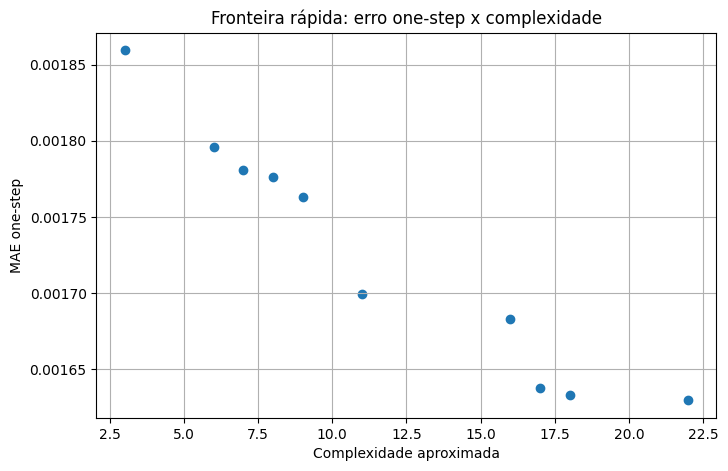

In [27]:
# ============================================================
# 7) FRONTEIRA RÁPIDA
# ============================================================

X_pareto = np.atleast_2d(res.X)
F_pareto = np.atleast_2d(res.F)

linhas = []

for x, f in zip(X_pareto, F_pareto):
    cfg = decodificar_x(x)

    if f[0] >= 1e5:
        continue

    linhas.append({
        "ny": cfg["ny"],
        "nu": cfg["nu"],
        "nd": cfg["nd"],
        "grau": cfg["grau"],
        "alpha": cfg["alpha"],
        "MAE_one_step": f[0],
        "complexidade": f[1]
    })

df_pareto = pd.DataFrame(linhas)

if len(df_pareto) == 0:
    raise RuntimeError("NSGA-II não encontrou modelos válidos.")

df_pareto = df_pareto.drop_duplicates(
    subset=["ny", "nu", "nd", "grau", "alpha"]
).sort_values(["MAE_one_step", "complexidade"]).reset_index(drop=True)

print("\nFronteira rápida encontrada:")
display(df_pareto.head(30))

plt.figure(figsize=(8, 5))
plt.scatter(df_pareto["complexidade"], df_pareto["MAE_one_step"])
plt.xlabel("Complexidade aproximada")
plt.ylabel("MAE one-step")
plt.title("Fronteira rápida: erro one-step x complexidade")
plt.grid(True)
plt.show()


In [28]:
# ============================================================
# 8) AVALIAÇÃO RECURSIVA APENAS NOS MELHORES CANDIDATOS
# ============================================================

print("\nAvaliando erro recursivo apenas nos melhores candidatos...")

N_CAND = min(N_CANDIDATOS_RECURSIVO, len(df_pareto))
mae_recursivos = []

for i in range(N_CAND):
    row = df_pareto.iloc[i]

    cfg = {
        "ny": int(row["ny"]),
        "nu": int(row["nu"]),
        "nd": int(row["nd"]),
        "grau": int(row["grau"]),
        "alpha": float(row["alpha"])
    }

    modelo_tmp, mae_one, rmse_one, complexidade = treinar_e_avaliar_one_step(cfg)
    mae_rec = erro_recursivo_validacao(
        modelo_tmp,
        cfg,
        n_segmentos=N_SEGMENTOS_RECURSIVO
    )

    mae_recursivos.append(mae_rec)

df_pareto["MAE_recursivo"] = np.nan
df_pareto.loc[:N_CAND-1, "MAE_recursivo"] = mae_recursivos

print("\nCandidatos com erro recursivo avaliado:")
display(df_pareto.head(N_CAND))



Avaliando erro recursivo apenas nos melhores candidatos...

Candidatos com erro recursivo avaliado:


,ny,nu,nd,grau,alpha,MAE_one_step,complexidade,MAE_recursivo
0,8,6,4,1,0.000008,0.001630,22.0,0.019602
1,8,2,4,1,0.000009,0.001633,18.0,0.019898
2,8,1,4,1,0.000011,0.001638,17.0,0.018468
3,6,4,3,1,0.000008,0.001683,16.0,0.017517
4,2,1,4,1,0.437848,0.001699,11.0,0.019238
5,2,1,3,1,0.436393,0.001763,9.0,0.020291
6,2,6,0,1,0.000006,0.001776,8.0,0.021507
7,2,5,0,1,0.291334,0.001781,7.0,0.020236
8,2,4,0,1,0.000015,0.001796,6.0,0.021235
9,2,1,0,1,0.437848,0.001859,3.0,0.022367



Modelo NARX escolhido:
{'ny': 6, 'nu': 4, 'nd': 3, 'grau': 1, 'alpha': 8.245947934119244e-06}

Linha do modelo escolhido:


,ny,nu,nd,grau,alpha,MAE_one_step,complexidade,MAE_recursivo
3,6.0,4.0,3.0,1.0,0.000008,0.001683,16.0,0.017517


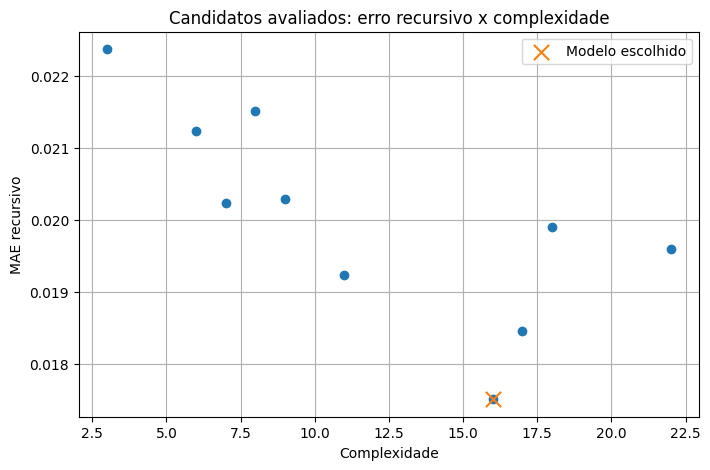

In [29]:
# ============================================================
# 9) ESCOLHA DO MODELO FINAL
# ============================================================

df_validos = df_pareto.dropna(subset=["MAE_recursivo"]).copy()

F = df_validos[["MAE_one_step", "MAE_recursivo", "complexidade"]].values
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)

score = (
    PESO_MAE_ONE * F_norm[:, 0] +
    PESO_MAE_REC * F_norm[:, 1] +
    PESO_COMPLEX * F_norm[:, 2]
)

idx_best = int(np.argmin(score))
best_row = df_validos.iloc[idx_best]

best_cfg = {
    "ny": int(best_row["ny"]),
    "nu": int(best_row["nu"]),
    "nd": int(best_row["nd"]),
    "grau": int(best_row["grau"]),
    "alpha": float(best_row["alpha"])
}

print("\nModelo NARX escolhido:")
print(best_cfg)
print("\nLinha do modelo escolhido:")
display(best_row.to_frame().T)

plt.figure(figsize=(8, 5))
plt.scatter(df_validos["complexidade"], df_validos["MAE_recursivo"])
plt.scatter(
    [best_row["complexidade"]],
    [best_row["MAE_recursivo"]],
    s=120,
    marker="x",
    label="Modelo escolhido"
)
plt.xlabel("Complexidade")
plt.ylabel("MAE recursivo")
plt.title("Candidatos avaliados: erro recursivo x complexidade")
plt.grid(True)
plt.legend()
plt.show()



Desempenho one-step no teste:
MAE  = 0.001467
RMSE = 0.002579
Número de termos: 16


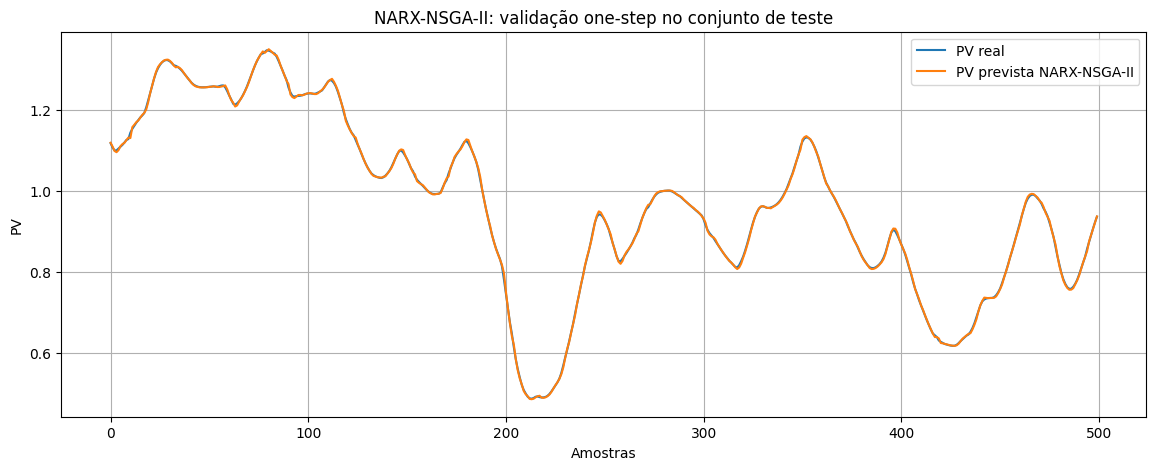

In [30]:
# ============================================================
# 10) RETREINAMENTO FINAL EM TREINO + VALIDAÇÃO
# ============================================================

X_all, y_all, idx_t_all = montar_Xy_narx(df, best_cfg, horizonte=1)

mask_fit = idx_t_all < IDX_VAL_END
mask_test = idx_t_all >= IDX_VAL_END

X_fit, y_fit = X_all[mask_fit], y_all[mask_fit]
X_test, y_test = X_all[mask_test], y_all[mask_test]

modelo_narx = criar_pipeline_narx(best_cfg)
modelo_narx.fit(X_fit, y_fit)

y_pred_test = modelo_narx.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\nDesempenho one-step no teste:")
print(f"MAE  = {mae_test:.6f}")
print(f"RMSE = {rmse_test:.6f}")
print("Número de termos:", modelo_narx.named_steps["poly"].n_output_features_)

plt.figure(figsize=(14, 5))
plt.plot(y_test[:500], label="PV real")
plt.plot(y_pred_test[:500], label="PV prevista NARX-NSGA-II")
plt.title("NARX-NSGA-II: validação one-step no conjunto de teste")
plt.xlabel("Amostras")
plt.ylabel(COL_PV)
plt.legend()
plt.grid(True)
plt.show()



Teste recursivo final do NARX escolhido:
h | PV real | PV prevista
 1 | 1.1146 | 1.1167
 2 | 1.1207 | 1.1238
 3 | 1.1268 | 1.1307
 4 | 1.1290 | 1.1374
 5 | 1.1450 | 1.1436
 6 | 1.1543 | 1.1493
 7 | 1.1620 | 1.1544
 8 | 1.1693 | 1.1589
 9 | 1.1760 | 1.1628
10 | 1.1823 | 1.1661


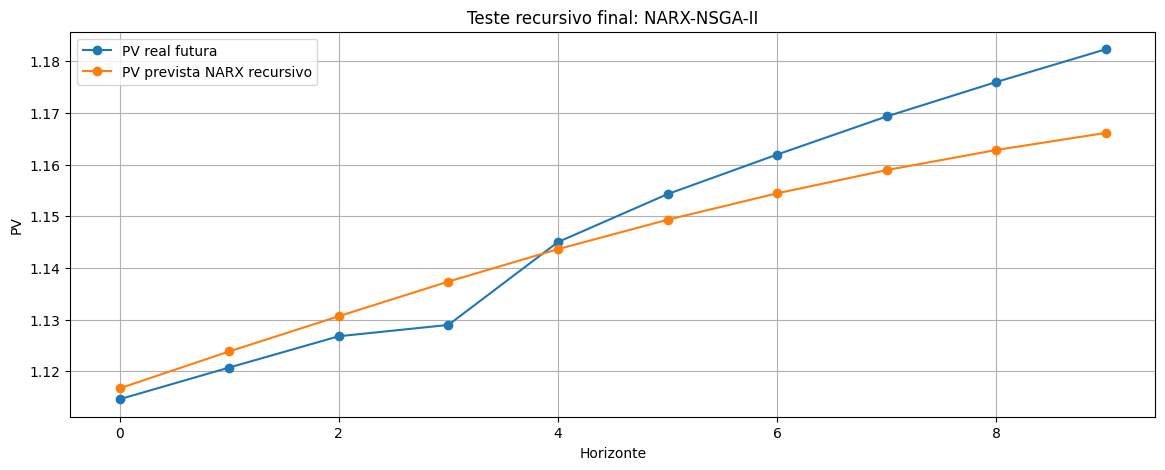

In [31]:
# ============================================================
# 11) TESTE RECURSIVO FINAL
# ============================================================

def simular_trajetoria_constante_u_narx(janela_atual, u_candidato, indice_base, horizonte_np):
    janela = janela_atual.copy()
    previsoes = []

    idx_pv = COL_FEATURES.index(COL_PV)
    idx_mv = COL_FEATURES.index(COL_MV)
    idx_exog = [COL_FEATURES.index(c) for c in COL_EXOGENAS]

    for h in range(horizonte_np):
        janela[-1, idx_mv] = u_candidato

        exog = obter_exogenas_no_indice(df, indice_base + h)
        for j, idx_col in enumerate(idx_exog):
            janela[-1, idx_col] = exog[j]

        y_next = prever_narx_janela(janela, modelo_narx, best_cfg)
        previsoes.append(y_next)

        nova_linha = janela[-1, :].copy()
        nova_linha[idx_pv] = y_next
        nova_linha[idx_mv] = u_candidato

        exog_next = obter_exogenas_no_indice(df, indice_base + h + 1)
        for j, idx_col in enumerate(idx_exog):
            nova_linha[idx_col] = exog_next[j]

        janela = np.vstack([janela[1:], nova_linha])

    return np.array(previsoes)


maxlag_best = max(best_cfg["ny"], best_cfg["nu"], best_cfg["nd"], 1)

k_teste = max(IDX_VAL_END + maxlag_best, maxlag_best)
k_teste = min(k_teste, len(df) - HORIZONTE_RECURSIVO - 2)

janela_teste = df.loc[k_teste - maxlag_best + 1:k_teste, COL_FEATURES].values.astype(float)
u_atual = float(janela_teste[-1, COL_FEATURES.index(COL_MV)])

previsoes_rec = simular_trajetoria_constante_u_narx(
    janela_atual=janela_teste,
    u_candidato=u_atual,
    indice_base=k_teste,
    horizonte_np=HORIZONTE_RECURSIVO
)

pv_real_futura = df.loc[k_teste + 1:k_teste + HORIZONTE_RECURSIVO, COL_PV].values.astype(float)

print("\nTeste recursivo final do NARX escolhido:")
print("h | PV real | PV prevista")
for h in range(min(HORIZONTE_RECURSIVO, len(pv_real_futura))):
    print(f"{h+1:2d} | {pv_real_futura[h]:.4f} | {previsoes_rec[h]:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(pv_real_futura, marker="o", label="PV real futura")
plt.plot(previsoes_rec[:len(pv_real_futura)], marker="o", label="PV prevista NARX recursivo")
plt.title("Teste recursivo final: NARX-NSGA-II")
plt.xlabel("Horizonte")
plt.ylabel(COL_PV)
plt.legend()
plt.grid(True)
plt.show()


In [32]:
# ============================================================
# 12) TESTE DE SENSIBILIDADE DA MV
# ============================================================

print("\nTeste de sensibilidade da MV no horizonte:")

for du in [-10, -5, 0, 5, 10]:
    u_teste = np.clip(u_atual + du, U_MIN, U_MAX)

    prev = simular_trajetoria_constante_u_narx(
        janela_atual=janela_teste,
        u_candidato=u_teste,
        indice_base=k_teste,
        horizonte_np=HORIZONTE_RECURSIVO
    )

    print(f"\nMV constante = {u_teste:.4f}")
    print(f"PV inicial prevista: {prev[0]:.4f}")
    print(f"PV em 5 passos:      {prev[min(4, len(prev)-1)]:.4f}")
    print(f"PV em 10 passos:     {prev[min(9, len(prev)-1)]:.4f}")



Teste de sensibilidade da MV no horizonte:

MV constante = 22.2259
PV inicial prevista: 1.1321
PV em 5 passos:      1.1422
PV em 10 passos:     1.1470

MV constante = 27.2259
PV inicial prevista: 1.1244
PV em 5 passos:      1.1429
PV em 10 passos:     1.1566

MV constante = 32.2259
PV inicial prevista: 1.1167
PV em 5 passos:      1.1436
PV em 10 passos:     1.1661

MV constante = 37.2259
PV inicial prevista: 1.1090
PV em 5 passos:      1.1444
PV em 10 passos:     1.1757

MV constante = 42.2259
PV inicial prevista: 1.1013
PV em 5 passos:      1.1451
PV em 10 passos:     1.1853


In [41]:
# ============================================================
# 13) FUNÇÕES DO MPC COM NARX
# ============================================================

def prever_um_passo_janela_raw(janela_raw):
    return prever_narx_janela(janela_raw, modelo_narx, best_cfg)


def simular_trajetoria_constante_u(janela_atual, u_candidato, indice_base, horizonte_np):
    return simular_trajetoria_constante_u_narx(
        janela_atual=janela_atual,
        u_candidato=u_candidato,
        indice_base=indice_base,
        horizonte_np=horizonte_np
    )


def custo_mpc(previsoes, u_candidato, u_atual, indice_base):
    custo_erro = 0.0

    # Escalas para normalização
    escala_pv = max(1e-6, df[COL_PV].max() - df[COL_PV].min())
    escala_u = max(1e-6, U_MAX - U_MIN)

    for h, y_hat in enumerate(previsoes):
        sp = obter_sp_no_indice(df, indice_base + h + 1)

        erro_norm = (sp - y_hat) / escala_pv
        custo_erro += erro_norm ** 2

    delta_u_norm = (u_candidato - u_atual) / escala_u
    custo_du = LAMBDA_DU * (delta_u_norm ** 2)

    return custo_erro + custo_du


def escolher_acao_mpc(janela_atual, indice_base):
    u_atual = float(janela_atual[-1, COL_FEATURES.index(COL_MV)])

    melhor_u = u_atual
    melhor_custo = np.inf
    melhor_previsao = None

    for du in DELTA_U_CANDIDATOS:
        u_cand = np.clip(u_atual + du, U_MIN, U_MAX)

        previsoes = simular_trajetoria_constante_u(
            janela_atual=janela_atual,
            u_candidato=u_cand,
            indice_base=indice_base,
            horizonte_np=NP
        )

        J = custo_mpc(previsoes, u_cand, u_atual, indice_base)

        if J < melhor_custo:
            melhor_custo = J
            melhor_u = u_cand
            melhor_previsao = previsoes

    return melhor_u, melhor_custo, melhor_previsao


In [68]:
NP = 5
LAMBDA_DU = 0.01
DELTA_U_CANDIDATOS = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
MAX_PASSOS_MPC = 5000
U_MIN = 0
U_MAX = 100


Rodando MPC...
Modo: closed_loop_virtual
Início: 133105
Fim: 138105
NP: 5
Ações candidatas ΔU: [-2. -1.  0.  1.  2.]
Lambda DU: 0.01


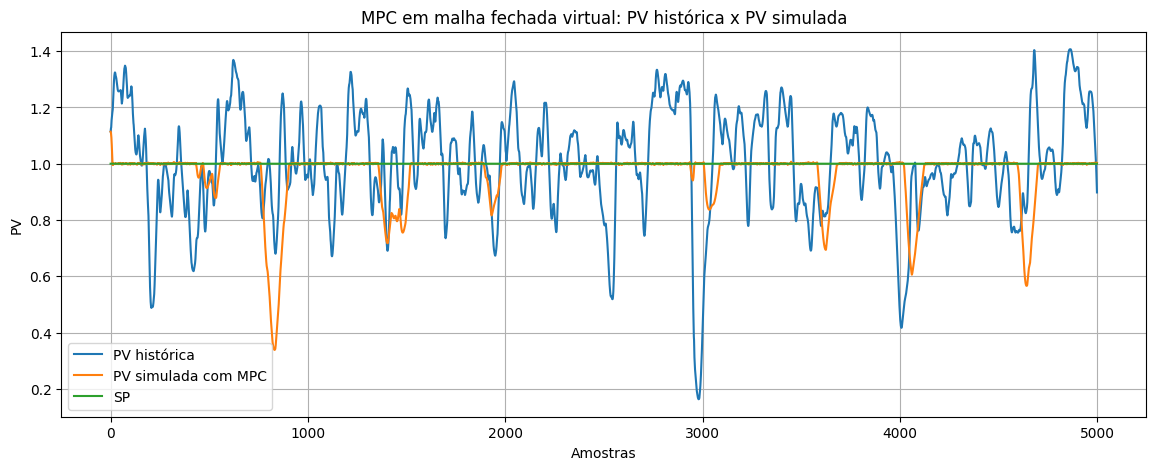

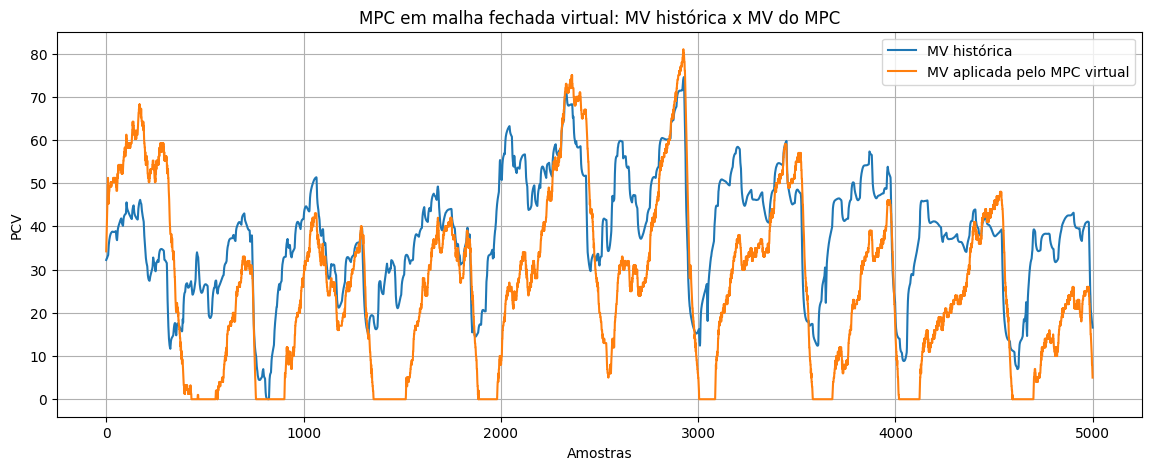

In [69]:
# ============================================================
# 14) EXECUÇÃO DO MPC
# ============================================================

inicio_mpc = max(IDX_VAL_END + maxlag_best, maxlag_best)
fim_mpc = min(len(df) - NP - 2, inicio_mpc + MAX_PASSOS_MPC)

print("\nRodando MPC...")
print("Modo:", MODO_MPC)
print("Início:", inicio_mpc)
print("Fim:", fim_mpc)
print("NP:", NP)
print("Ações candidatas ΔU:", DELTA_U_CANDIDATOS)
print("Lambda DU:", LAMBDA_DU)

u_mpc_lista = []
u_hist_lista = []
pv_real_lista = []
pv_sim_lista = []
sp_lista = []
custos_lista = []
tempos_mpc_ms = []

idx_pv = COL_FEATURES.index(COL_PV)
idx_mv = COL_FEATURES.index(COL_MV)
idx_exog = [COL_FEATURES.index(c) for c in COL_EXOGENAS]

if MODO_MPC == "shadow":

    for k in range(inicio_mpc, fim_mpc):
        janela_real = df.loc[k - maxlag_best + 1:k, COL_FEATURES].values.astype(float)

        t0 = time.perf_counter()
        u_mpc, J, previsoes = escolher_acao_mpc(janela_real, k)
        t1 = time.perf_counter()

        tempos_mpc_ms.append((t1 - t0) * 1000.0)

        u_mpc_lista.append(u_mpc)
        u_hist_lista.append(float(df.loc[k, COL_MV]))
        pv_real_lista.append(float(df.loc[k, COL_PV]))
        sp_lista.append(obter_sp_no_indice(df, k))
        custos_lista.append(J)

    plt.figure(figsize=(14, 5))
    plt.plot(pv_real_lista, label="PV histórica")
    plt.plot(sp_lista, label="SP")
    plt.title("MPC modo sombra: PV histórica e SP")
    plt.xlabel("Amostras")
    plt.ylabel(COL_PV)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(u_hist_lista, label="MV histórica")
    plt.plot(u_mpc_lista, label="MV recomendada pelo MPC")
    plt.title("MPC modo sombra: MV histórica x MV recomendada")
    plt.xlabel("Amostras")
    plt.ylabel(COL_MV)
    plt.legend()
    plt.grid(True)
    plt.show()

elif MODO_MPC == "closed_loop_virtual":

    janela_sim = df.loc[inicio_mpc - maxlag_best + 1:inicio_mpc, COL_FEATURES].values.astype(float)

    for k in range(inicio_mpc, fim_mpc):
        t0 = time.perf_counter()
        u_mpc, J, previsoes = escolher_acao_mpc(janela_sim, k)
        t1 = time.perf_counter()

        tempos_mpc_ms.append((t1 - t0) * 1000.0)

        janela_aplicacao = janela_sim.copy()
        janela_aplicacao[-1, idx_mv] = u_mpc

        exog = obter_exogenas_no_indice(df, k)
        for j, idx_col in enumerate(idx_exog):
            janela_aplicacao[-1, idx_col] = exog[j]

        pv_next = prever_um_passo_janela_raw(janela_aplicacao)

        nova_linha = janela_aplicacao[-1, :].copy()
        nova_linha[idx_pv] = pv_next
        nova_linha[idx_mv] = u_mpc

        exog_next = obter_exogenas_no_indice(df, k + 1)
        for j, idx_col in enumerate(idx_exog):
            nova_linha[idx_col] = exog_next[j]

        janela_sim = np.vstack([janela_sim[1:], nova_linha])

        u_mpc_lista.append(u_mpc)
        u_hist_lista.append(float(df.loc[k, COL_MV]))
        pv_real_lista.append(float(df.loc[k + 1, COL_PV]))
        pv_sim_lista.append(pv_next)
        sp_lista.append(obter_sp_no_indice(df, k + 1))
        custos_lista.append(J)

    plt.figure(figsize=(14, 5))
    plt.plot(pv_real_lista, label="PV histórica")
    plt.plot(pv_sim_lista, label="PV simulada com MPC")
    plt.plot(sp_lista, label="SP")
    plt.title("MPC em malha fechada virtual: PV histórica x PV simulada")
    plt.xlabel("Amostras")
    plt.ylabel(COL_PV)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(u_hist_lista, label="MV histórica")
    plt.plot(u_mpc_lista, label="MV aplicada pelo MPC virtual")
    plt.title("MPC em malha fechada virtual: MV histórica x MV do MPC")
    plt.xlabel("Amostras")
    plt.ylabel(COL_MV)
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    raise ValueError("MODO_MPC deve ser 'shadow' ou 'closed_loop_virtual'.")




Resumo do MPC:
Modo: closed_loop_virtual
Horizonte NP: 5
Número de ações candidatas: 5
Avaliações aproximadas do modelo por ciclo: 25

Tempo computacional do MPC no Colab:
Média:  43.1419 ms
Máximo: 444.1194 ms
Mínimo: 36.4896 ms

Comparação de erro:
MAE histórico:    0.146328
MAE MPC virtual:  0.034917


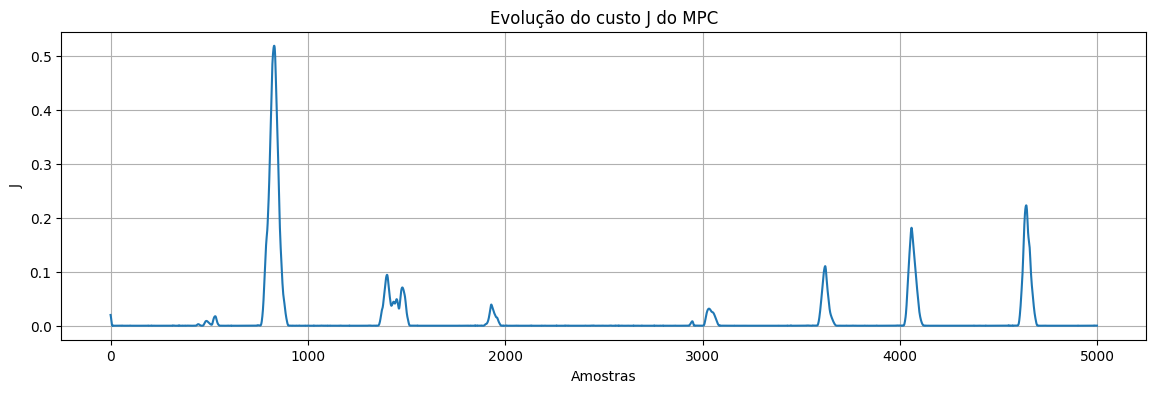

In [70]:
# ============================================================
# 15) MÉTRICAS DO MPC
# ============================================================

print("\nResumo do MPC:")
print(f"Modo: {MODO_MPC}")
print(f"Horizonte NP: {NP}")
print(f"Número de ações candidatas: {len(DELTA_U_CANDIDATOS)}")
print(f"Avaliações aproximadas do modelo por ciclo: {NP * len(DELTA_U_CANDIDATOS)}")

if len(tempos_mpc_ms) > 0:
    print("\nTempo computacional do MPC no Colab:")
    print(f"Média:  {np.mean(tempos_mpc_ms):.4f} ms")
    print(f"Máximo: {np.max(tempos_mpc_ms):.4f} ms")
    print(f"Mínimo: {np.min(tempos_mpc_ms):.4f} ms")

if MODO_MPC == "closed_loop_virtual" and len(pv_sim_lista) > 0:
    erro_hist = np.array(sp_lista) - np.array(pv_real_lista)
    erro_mpc = np.array(sp_lista) - np.array(pv_sim_lista)

    print("\nComparação de erro:")
    print(f"MAE histórico:    {np.mean(np.abs(erro_hist)):.6f}")
    print(f"MAE MPC virtual:  {np.mean(np.abs(erro_mpc)):.6f}")

plt.figure(figsize=(14, 4))
plt.plot(custos_lista)
plt.title("Evolução do custo J do MPC")
plt.xlabel("Amostras")
plt.ylabel("J")
plt.grid(True)
plt.show()

In [71]:


# ============================================================
# 16) EXPORTAÇÃO DO MODELO PARA IMPLEMENTAÇÃO
# ============================================================

def exportar_modelo_narx_para_excel(nome_arquivo="modelo_narx_nsga2_para_plc.xlsx"):
    scaler = modelo_narx.named_steps["scaler"]
    poly = modelo_narx.named_steps["poly"]
    ridge = modelo_narx.named_steps["ridge"]

    nomes_lags = montar_nomes_lags(best_cfg)
    powers = poly.powers_

    df_config = pd.DataFrame([{
        "ny": best_cfg["ny"],
        "nu": best_cfg["nu"],
        "nd": best_cfg["nd"],
        "grau": best_cfg["grau"],
        "alpha": best_cfg["alpha"],
        "col_pv": COL_PV,
        "col_mv": COL_MV,
        "col_sp": COL_SP,
        "col_exogenas": ", ".join(COL_EXOGENAS),
        "intercept": ridge.intercept_
    }])

    df_scaler = pd.DataFrame({
        "feature": nomes_lags,
        "mean": scaler.mean_,
        "scale": scaler.scale_
    })

    df_terms = pd.DataFrame(powers, columns=nomes_lags)
    df_terms.insert(0, "coef", ridge.coef_)
    df_terms.insert(0, "term_id", np.arange(len(df_terms)))

    with pd.ExcelWriter(nome_arquivo, engine="openpyxl") as writer:
        df_config.to_excel(writer, sheet_name="config", index=False)
        df_scaler.to_excel(writer, sheet_name="scaler", index=False)
        df_terms.to_excel(writer, sheet_name="terms", index=False)
        df_pareto.to_excel(writer, sheet_name="pareto", index=False)

    return nome_arquivo

arquivo_exportado = exportar_modelo_narx_para_excel()

print("\nModelo exportado para:")
print(arquivo_exportado)

try:
    from google.colab import files
    files.download(arquivo_exportado)
except Exception:
    pass


Modelo exportado para:
modelo_narx_nsga2_para_plc.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
print("U_MIN =", U_MIN)
print("U_MAX =", U_MAX)
print("MV histórica min:", df[COL_MV].min())
print("MV histórica max:", df[COL_MV].max())
print("MV MPC min:", np.min(u_mpc_lista))
print("MV MPC max:", np.max(u_mpc_lista))
print("Valores únicos aproximados:", np.unique(np.round(u_mpc_lista, 3))[:20])

U_MIN = 10.021440000000002
U_MAX = 100.0
MV histórica min: 4.23193e-29
MV histórica max: 100.0
MV MPC min: 32.2259
MV MPC max: 32.2259
Valores únicos aproximados: [32.226]


In [46]:
k = inicio_mpc
janela_debug = df.loc[k - maxlag_best + 1:k, COL_FEATURES].values.astype(float)

u_atual = float(janela_debug[-1, COL_FEATURES.index(COL_MV)])

print("u_atual =", u_atual)

for du in [-10, -5, 0, 5, 10]:
    u_cand = np.clip(u_atual + du, U_MIN, U_MAX)

    prev = simular_trajetoria_constante_u(
        janela_atual=janela_debug,
        u_candidato=u_cand,
        indice_base=k,
        horizonte_np=NP
    )

    print(
        f"du={du:+.1f} | u={u_cand:.2f} | "
        f"PV inicial={prev[0]:.4f} | "
        f"PV final={prev[-1]:.4f} | "
        f"PV média={np.mean(prev):.4f}"
    )

u_atual = 32.2259
du=-10.0 | u=22.23 | PV inicial=1.1321 | PV final=1.1470 | PV média=1.1412
du=-5.0 | u=27.23 | PV inicial=1.1244 | PV final=1.1566 | PV média=1.1428
du=+0.0 | u=32.23 | PV inicial=1.1167 | PV final=1.1661 | PV média=1.1444
du=+5.0 | u=37.23 | PV inicial=1.1090 | PV final=1.1757 | PV média=1.1460
du=+10.0 | u=42.23 | PV inicial=1.1013 | PV final=1.1853 | PV média=1.1476
